In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlxtend


# Dataset and Sampling

Working on first 50000 order data for apriori and fpgrowth due to the computers lack of ram


For GSP we will be working with full dataset to observe better patterns

In [61]:
raw_df = pd.read_csv("dataset_son.csv")

# df = pd.read_csv("dataset_son.csv")

df = raw_df.head(50000)
df.to_csv("sample_50000_rows.csv", index=False)


Basket Size Analysis

In [62]:
# product count
df["product_count"] = df["product_id"].apply(
    lambda x: len(str(x).split(","))
)

print(df[["product_id", "product_count"]].head())

mean_basket = df["product_count"].mean()
median_basket = df["product_count"].median()

print("Mean basket size:", mean_basket)
print("Median basket size:", median_basket)

print(df["product_count"].describe())


                                          product_id  product_count
0  33120, 28985, 9327, 45918, 30035, 17794, 40141...              9
1  33754, 24838, 17704, 21903, 17668, 46667, 1746...              8
2  46842, 26434, 39758, 27761, 10054, 21351, 2259...             13
3  13176, 15005, 47329, 27966, 23909, 48370, 1324...             26
4                                40462, 15873, 41897              3
Mean basket size: 10.0787
Median basket size: 8.0
count    50000.00000
mean        10.07870
std          7.52976
min          1.00000
25%          5.00000
50%          8.00000
75%         14.00000
max         92.00000
Name: product_count, dtype: float64


Customer Purchase Frequency

In [63]:
customer_orders = df.groupby("user_id")["order_id"].nunique()

print(customer_orders.head())

print(customer_orders.describe())

customer_segments = pd.cut(
    customer_orders,
    bins=[0, 3, 9, float("inf")],
    labels=["Infrequent (1-3 order)", "Regular (4-9 orders)", "Frequent (10+ orders)"]
)

print(customer_segments.value_counts())



user_id
7     1
13    1
23    1
27    1
36    1
Name: order_id, dtype: int64
count    40087.000000
mean         1.247287
std          0.570256
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          9.000000
Name: order_id, dtype: float64
order_id
Infrequent (1-3 order)    39712
Regular (4-9 orders)        375
Frequent (10+ orders)         0
Name: count, dtype: int64


Pareto Analysis

In [64]:
df["product_list"] = df["product_id"].apply(
    lambda x: [i.strip() for i in str(x).split(",") if i.strip()]
)


product_df = df.explode("product_list")

product_freq = product_df["product_list"].value_counts()

print(product_freq.head())

pareto_df = product_freq.reset_index()
pareto_df.columns = ["product_id", "frequency"]

pareto_df["cumulative"] = pareto_df["frequency"].cumsum()
pareto_df["cumulative_pct"] = pareto_df["cumulative"] / pareto_df["frequency"].sum() * 100

products_80 = pareto_df[pareto_df["cumulative_pct"] <= 80]

num_products_80 = len(products_80)
total_products = len(pareto_df)

percentage = (num_products_80 / total_products) * 100

print(f"{num_products_80} out of {total_products} products account for 80% of sales")
print(f"That is {percentage:.2f}% of all products")


product_list
24852    7422
13176    5965
21137    4059
21903    3822
47209    3342
Name: count, dtype: int64
4461 out of 29267 products account for 80% of sales
That is 15.24% of all products


Basket Size Plots

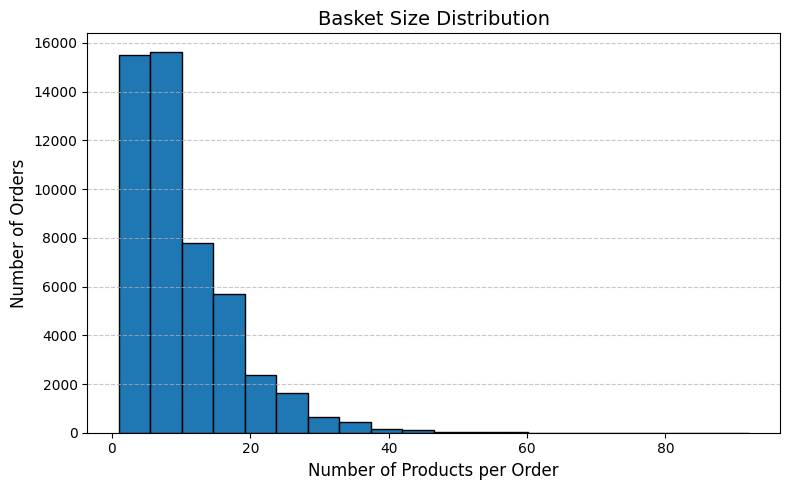

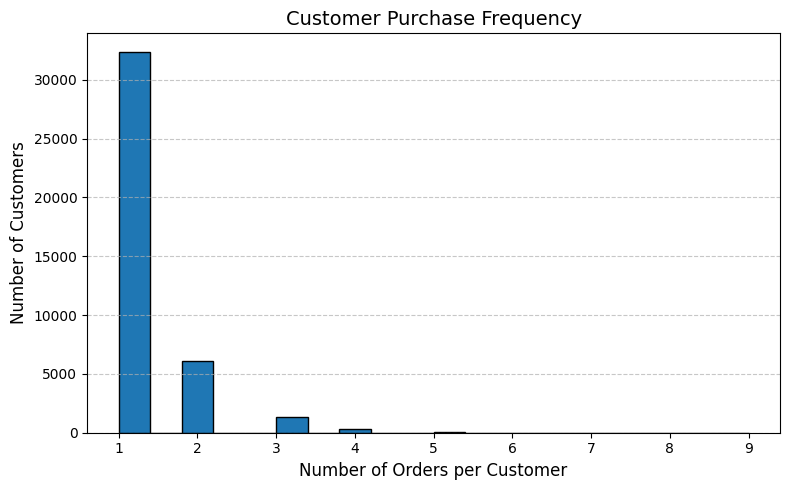

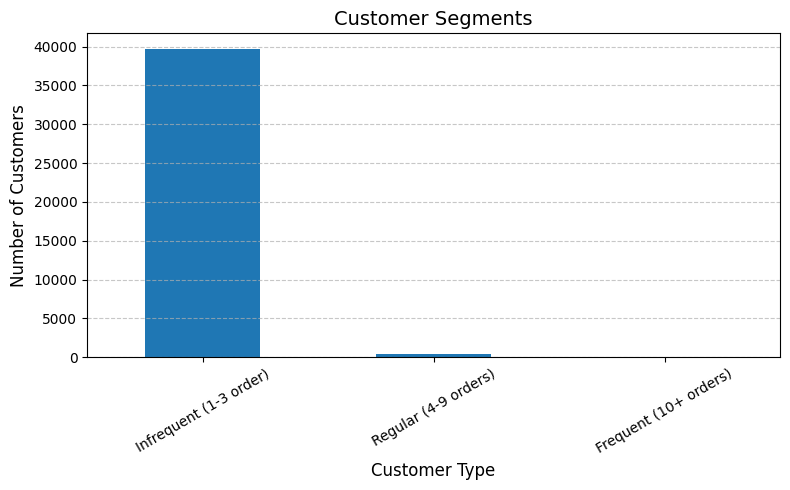

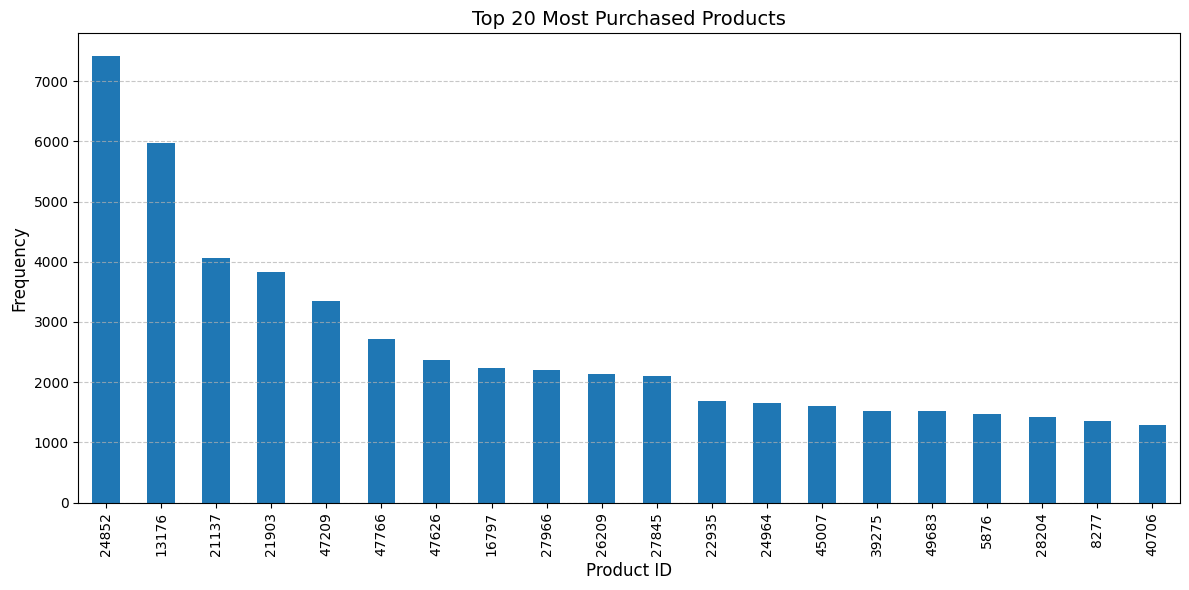

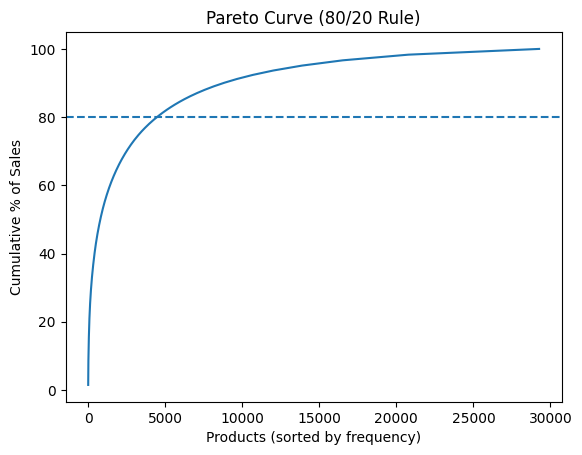

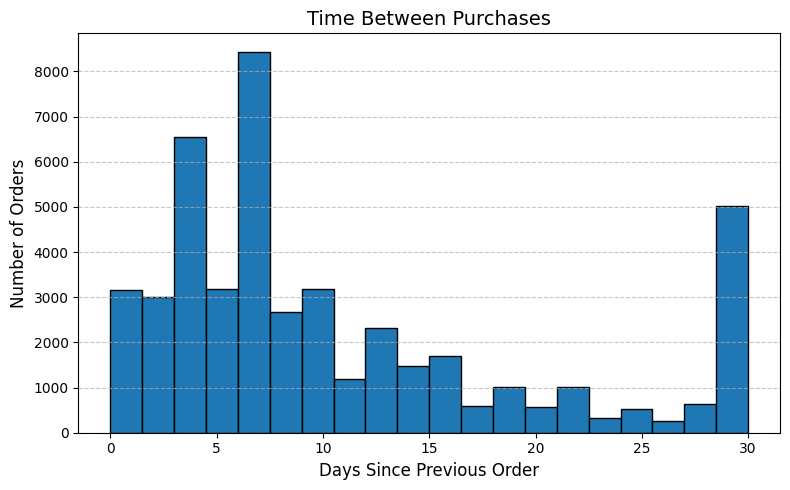

In [112]:
# Product count

df["product_count"] = df["product_id"].apply(
    lambda x: len([i.strip() for i in str(x).split(",") if i.strip()])
)

plt.figure(figsize=(8,5))
plt.hist(df["product_count"], bins=20, edgecolor="black")

plt.title("Basket Size Distribution", fontsize=14)
plt.xlabel("Number of Products per Order", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Customer Purchase Frequency 
plt.figure(figsize=(8,5))
plt.hist(customer_orders, bins=20, edgecolor="black")

plt.title("Customer Purchase Frequency", fontsize=14)
plt.xlabel("Number of Orders per Customer", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Customer Segmentation 

segment_counts = customer_segments.value_counts().sort_index()

plt.figure(figsize=(8,5))
segment_counts.plot(kind="bar")

plt.title("Customer Segments", fontsize=14)
plt.xlabel("Customer Type", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Product Frequency 

plt.figure(figsize=(12,6))
product_freq.head(20).plot(kind="bar")

plt.title("Top 20 Most Purchased Products", fontsize=14)
plt.xlabel("Product ID", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Pareto Visualization
plt.figure()
plt.plot(pareto_df["cumulative_pct"])
plt.axhline(y=80, linestyle="--")
plt.title("Pareto Curve (80/20 Rule)")
plt.xlabel("Products (sorted by frequency)")
plt.ylabel("Cumulative % of Sales")
plt.show()

# Time-between Purchases
plt.figure(figsize=(8,5))
plt.hist(df["days_since_prior_order"].dropna(), bins=20, edgecolor="black")

plt.title("Time Between Purchases", fontsize=14)
plt.xlabel("Days Since Previous Order", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [90]:
df["product_list"] = df["product_id"].apply(
    lambda x: [i.strip() for i in str(x).split(",") if i.strip()]
)

transactions = df.explode("product_list")

transactions = transactions[["order_id", "product_list"]]

basket = (transactions
          .groupby(["order_id", "product_list"])["product_list"]
          .count()
          .unstack()
          .fillna(0))

basket = (basket > 0).astype(int)

print(basket.head()) # all zeroes - sparse matrix

product_list  1  10  100  1000  10004  10005  10006  10008  10009  10010  ...  \
order_id                                                                  ...   
2             0   0    0     0      0      0      0      0      0      0  ...   
3             0   0    0     0      0      0      0      0      0      0  ...   
4             0   0    0     0      0      0      0      0      0      0  ...   
5             0   0    0     0      0      0      0      0      0      0  ...   
6             0   0    0     0      0      0      0      0      0      0  ...   

product_list  9979  9980  9983  9985  9987  999  9990  9995  9996  9997  
order_id                                                                 
2                0     0     0     0     0    0     0     0     0     0  
3                0     0     0     0     0    0     0     0     0     0  
4                0     0     0     0     0    0     0     0     0     0  
5                0     0     0     0     0    0     0     0   

# Association Mining

# Apriori Analysis

In [91]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

# For memory and time comparisons
import time
import psutil
import os

start = time.time()

process = psutil.Process(os.getpid()) 
mem_before = process.memory_info().rss / (1024**2)


# Apriori
frequent_itemsets = apriori(
    basket,
    min_support=0.005, 
    use_colnames=True
)

print("Frequent Itemsets:")
print(frequent_itemsets.sort_values(by="support", ascending=False).head())

rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=2
)


rules = rules[
    (rules["confidence"] >= 0.15) &
    (rules["lift"] > 1)
].copy()



rules["antecedents"] = rules["antecedents"].apply(lambda x: ", ".join(list(x)))
rules["consequents"] = rules["consequents"].apply(lambda x: ", ".join(list(x)))

# Top 5 by Support
top_support = rules.sort_values(by="support", ascending=False).head(5)

print("\nTop 5 Rules by Support")
print(top_support[["antecedents", "consequents", "support", "confidence", "lift"]])

# Top 5 by Confidence

top_conf = rules.sort_values(by="confidence", ascending=False).head(5)

print("\nTop 5 Rules by Confidence")
print(top_conf[["antecedents", "consequents", "support", "confidence", "lift"]])

# Top 5 by Lift
top_lift = rules.sort_values(by="lift", ascending=False).head(5)

print("\nTop 5 Rules by Lift")
print(top_lift[["antecedents", "consequents", "support", "confidence", "lift"]])

#  memory
mem_after = process.memory_info().rss / (1024**2)
apriori_memory = mem_after - mem_before

print("Apriori memory usage (MB):", apriori_memory)

# time

end = time.time()
apriori_time = end - start

print("Apriori runtime:", apriori_time)



c:\Users\ab165988\AppData\Local\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Frequent Itemsets:
     support            itemsets
74   0.14844  frozenset({24852})
10   0.11930  frozenset({13176})
52   0.08118  frozenset({21137})
58   0.07644  frozenset({21903})
218  0.06684  frozenset({47209})

Top 5 Rules by Support
   antecedents consequents  support  confidence      lift
10       47209       13176  0.01920    0.287253  2.407822
11       13176       47209  0.01920    0.160939  2.407822
55       47766       24852  0.01676    0.307862  2.073982
2        27966       13176  0.01340    0.305378  2.559751
24       21137       47209  0.01270    0.156442  2.340552

Top 5 Rules by Confidence
   antecedents consequents  support  confidence      lift
48       28204       24852  0.01028    0.361972  2.438506
50       45066       24852  0.00918    0.358034  2.411980
58       49683       24852  0.01012    0.331152  2.230880
1        19057       13176  0.00754    0.325843  2.731288
55       47766       24852  0.01676    0.307862  2.073982

Top 5 Rules by Lift
   antecedents 

Analysis:

For our sample data with 50000 orders:

Fine tuned values: lift = 1 - confidence = 0.15 - support 0.005

Frequent Items: 24852 - 14.84% / 13176 - 11.93% / 21137 - %8.18

# FP GROWTH

In [ ]:
from mlxtend.frequent_patterns import fpgrowth


start = time.time()

process = psutil.Process(os.getpid()) 
mem_before = process.memory_info().rss / (1024**2)

frequent_itemsets_fp = fpgrowth(
    basket,
    min_support=0.005,   # same as apriori
    use_colnames=True
)

print("Frequent Itemsets (FP-Growth):")
print(frequent_itemsets_fp.sort_values(by="support", ascending=False).head())


rules_fp = association_rules(
    frequent_itemsets_fp,
    metric="lift",
    min_threshold=1
)


rules_fp = rules_fp[
    (rules_fp["confidence"] >= 0.15) &
    (rules_fp["lift"] > 1)
].copy()

# for recommendation model
rules_model = rules_fp.copy()

rules_fp["antecedents"] = rules_fp["antecedents"].apply(lambda x: ", ".join(list(x)))
rules_fp["consequents"] = rules_fp["consequents"].apply(lambda x: ", ".join(list(x)))



top_support_fp = rules_fp.sort_values(by="support", ascending=False).head(5)

print("\nFP-Growth - Top 5 Rules by SUPPORT")
print(top_support_fp[["antecedents", "consequents", "support", "confidence", "lift"]])

top_conf_fp = rules_fp.sort_values(by="confidence", ascending=False).head(5)

print("\nFP-Growth - Top 5 Rules by CONFIDENCE")
print(top_conf_fp[["antecedents", "consequents", "support", "confidence", "lift"]])

top_lift_fp = rules_fp.sort_values(by="lift", ascending=False).head(5)

print("\nFP-Growth - Top 5 Rules by LIFT")
print(top_lift_fp[["antecedents", "consequents", "support", "confidence", "lift"]])

# time and memory
mem_after = process.memory_info().rss / (1024**2)
fpgrowth_memory = mem_after - mem_before

print("FP-Growth memory usage (MB):", fpgrowth_memory)

end = time.time()
fpgrowth_time = end - start
print("FP-Growth runtime:", fpgrowth_time)

c:\Users\ab165988\AppData\Local\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Frequent Itemsets (FP-Growth):
    support            itemsets
21  0.14844  frozenset({24852})
9   0.11930  frozenset({13176})
22  0.08118  frozenset({21137})
3   0.07644  frozenset({21903})
10  0.06684  frozenset({47209})

FP-Growth - Top 5 Rules by SUPPORT
   antecedents consequents  support  confidence      lift
6        47209       13176  0.01920    0.287253  2.407822
7        13176       47209  0.01920    0.160939  2.407822
26       21137       13176  0.01874    0.230845  1.934996
27       13176       21137  0.01874    0.157083  1.934996
24       21137       24852  0.01834    0.225918  1.521946

FP-Growth - Top 5 Rules by CONFIDENCE
    antecedents consequents  support  confidence      lift
76        28204       24852  0.01028    0.361972  2.438506
46        45066       24852  0.00918    0.358034  2.411980
70        49683       24852  0.01012    0.331152  2.230880
121       19057       13176  0.00754    0.325843  2.731288
29        47766       24852  0.01676    0.307862  2.073982


# Apriori - FPGROWTH Comparison:

FP growth gave the same performance apriori when we compare lift, support and confidence. FP-growth's tree structure compresses the data while apriori generated itemsets seperately, which will cause memory and time differences.

Time:

 Firstly with 5k order data apriori took 1.05s and fpgrowth 0.4 seconds, however fpgrowth actually took more memory with 3.1mb vs 1mb on apriori which is an interesting observation.

50k rows sample data: fp growth took 1.16 minutes while apriori took 7.30 minutes. When we increased the parameters by doubling support lift and confidence, fpgrowth has taken 10.5s whereas apriori took 24s to run. We observe a exponential increase in apriori when we increase data size and lower the parameters, which makes it very hard to implement on large datasets. 


Memory:

FP- growth with our 50k dataset took 9.6GB memory, whereas apriori algorithm took 5.6 GB Memory, when we doubled the parameters, thereby lowering the rules we look for, FP-growth took 196MB while apriori took 560MB.

Normally we would expect FP-growth to take less memory as the dataset size increases due to its tree-structure, here we have an anomaly, however it is probably case-specific.

Conclusion: 

On large datasets, we observe fpgrowth gives almost same output and recognizes patterns with similar ability while being 3 times faster, however it has taken more memory in our application. 

# Sequential Rule Mining

Without constraints with pymining

In [ ]:
df_full = pd.read_csv("dataset_son.csv")
df_full = df_full[[
    "user_id",
    "order_id",
    "product_id",
    "days_since_prior_order"
]]


df_full = df_full.sort_values(by=["user_id", "order_id"])

df_full["product_list"] = df_full["product_id"].apply(
    lambda x: [i.strip() for i in str(x).split(",") if i.strip()]
)

df_full["product_list"] = df_full["product_id"].apply(
    lambda x: tuple(i.strip() for i in str(x).split(",") if i.strip())
)

user_sequences = df_full.groupby("user_id")["product_list"].apply(list)

sequences = user_sequences.tolist()

print(sequences[:2])


[[('196', '12427', '10258', '25133', '10326', '17122', '41787', '13176'), ('196', '12427', '10258', '25133', '30450'), ('196', '10258', '12427', '25133', '13032'), ('196', '12427', '10258', '25133', '26405'), ('49235', '46149', '25133', '196', '10258', '12427'), ('196', '10258', '12427', '13176', '26088', '13032'), ('196', '14084', '12427', '26088', '26405'), ('196', '46149', '39657', '38928', '25133', '10258', '35951', '13032', '12427'), ('12427', '196', '10258', '25133', '46149', '49235'), ('196', '12427', '10258', '25133')], [('49451', '32792', '32139', '34688', '36735', '37646', '22829', '24852', '47209', '33276', '45613', '9681', '21150'), ('32792', '28918', '24852', '34688', '48110', '47209', '32052', '17758', '40198', '46886', '22963', '23', '20084', '2002', '5212', '14306'), ('24852', '16589', '1559', '19156', '18523', '22825', '27413', '33754', '21709', '47209', '7781', '2573', '39928', '20785', '24768', '7963'), ('32792', '12000', '9681', '32139', '32052', '27344', '24852', '

Sequential Mining from pymining

Below code tried normal sequential mining on full data, even after 45 minutes the code didn't finish. Hence I will simply continue with GSP format. 

In [44]:
# after 45 min didn't stop running
# from pymining import seqmining

# min_support = 2

# freq_seqs = seqmining.freq_seq_enum(sequences, min_support)

# print(list(freq_seqs)[:10])

# GSP Applied

With min = 0 - max = 15 constraints:

In [ ]:
from collections import Counter

df_full["days_since_prior_order"] = df_full["days_since_prior_order"].fillna(0)

df_full["cumulative_days"] = df_full.groupby("user_id")["days_since_prior_order"].cumsum()

user_sequences_time = df_full.groupby("user_id").apply(
    lambda x: list(zip(x["product_list"], x["cumulative_days"]))
)

print(user_sequences_time.iloc[0])

def run_gsp_full(user_sequences_time, min_gap=0, max_gap=15, min_support=3):

    def gsp_pairs(sequence):
        pairs = []
        
        for i in range(len(sequence)):
            items_i, time_i = sequence[i]
            
            for j in range(i + 1, len(sequence)):
                items_j, time_j = sequence[j]
                
                gap = time_j - time_i
                
                if gap < min_gap:
                    continue
                if gap > max_gap:
                    break
                
                pairs.append((items_i, items_j))
        
        return pairs

    #  all patterns
    all_patterns = []
    for seq in user_sequences_time:
        all_patterns.extend(gsp_pairs(seq))

    #  support values
    pattern_counts = Counter(all_patterns)

    patterns_full = {
        p: c for p, c in pattern_counts.items() if c >= min_support
    }

    return patterns_full

[(('196', '12427', '10258', '25133', '10326', '17122', '41787', '13176'), 28.0), (('196', '12427', '10258', '25133', '30450'), 49.0), (('196', '10258', '12427', '25133', '13032'), 69.0), (('196', '12427', '10258', '25133', '26405'), 98.0), (('49235', '46149', '25133', '196', '10258', '12427'), 98.0), (('196', '10258', '12427', '13176', '26088', '13032'), 113.0), (('196', '14084', '12427', '26088', '26405'), 113.0), (('196', '46149', '39657', '38928', '25133', '10258', '35951', '13032', '12427'), 143.0), (('12427', '196', '10258', '25133', '46149', '49235'), 157.0), (('196', '12427', '10258', '25133'), 176.0)]


Explanation: (('196', '12427', '10258', '25133', '10326', '17122', '41787', '13176'), 28.0) means this pattern has been observed 28 times in our dataset

Below we filter patterns so that an item links to a single item to increase its interpretability. We also keep the initial rules for a comparison.

In [54]:
def filter_patterns(patterns_full, mode="simple"):
    
    if mode == "simple":
        # A → B
        return {
            p: c for p, c in patterns_full.items()
            if len(p[0]) == 1 and len(p[1]) == 1 and p[0] != p[1]
        }
    
    elif mode == "medium":
        # allow small groups
        return {
            p: c for p, c in patterns_full.items()
            if len(p[0]) <= 2 and len(p[1]) <= 2
        }
    
    else:
        # return full
        return patterns_full

Experimentation: Here is GSP applied with max = 5, 15, 25

In [ ]:
max_gaps = [5, 15, 25]

for gap in max_gaps:
    print(f"\n==============================")
    print(f"MAX GAP = {gap}")
    print(f"==============================")

    patterns_full = run_gsp_full(user_sequences_time, max_gap=gap, min_support=3)

    print("\nTop Full patterns:")
    print(Counter(patterns_full).most_common(5))

    patterns_simple = filter_patterns(patterns_full, mode="simple")

    print("\nTop Simple patterns (A → B):")
    print(Counter(patterns_simple).most_common(5))


MAX GAP = 5

Top Full patterns:
[((('46822',), ('46822',)), 249), ((('24852',), ('24852',)), 237), ((('19660',), ('19660',)), 173), ((('196',), ('196',)), 168), ((('40939',), ('40939',)), 124)]

Top Simple patterns (A → B):
[((('33249',), ('17902',)), 53), ((('17902',), ('33249',)), 48), ((('1463',), ('19677',)), 34), ((('19677',), ('1463',)), 24), ((('27729',), ('36036',)), 15)]

MAX GAP = 15

Top Full patterns:
[((('46822',), ('46822',)), 721), ((('24852',), ('24852',)), 672), ((('19660',), ('19660',)), 561), ((('196',), ('196',)), 558), ((('38928',), ('38928',)), 438)]

Top Simple patterns (A → B):
[((('33249',), ('17902',)), 130), ((('17902',), ('33249',)), 128), ((('1463',), ('19677',)), 62), ((('19677',), ('1463',)), 61), ((('23288',), ('21386',)), 48)]

MAX GAP = 25

Top Full patterns:
[((('46822',), ('46822',)), 1064), ((('24852',), ('24852',)), 1014), ((('19660',), ('19660',)), 997), ((('196',), ('196',)), 963), ((('38928',), ('38928',)), 737)]

Top Simple patterns (A → B):
[

# Recommendation System

Unknown User (Apriori and FP_growth)

In [ ]:
def recommend_unknown_user(rules_model, basket, top_n=5):

    basket_set = set(basket)
    recommendations = []

    for _, row in rules_model.iterrows():
        antecedents = set(row["antecedents"])
        consequents = set(row["consequents"])

        if antecedents.issubset(basket_set):
            for item in consequents:
                if item not in basket_set:
                    recommendations.append((item, row["lift"], row["confidence"]))

    recommendations = sorted(recommendations, key=lambda x: (-x[1], -x[2]))

    seen = set()
    final = []
    for item, _, _ in recommendations:
        if item not in seen:
            seen.add(item)
            final.append(item)

    return final[:top_n]

Recommendation Samples

In [ ]:
basket = ["13176"]
print("Basket:", basket)
print("Recommendations:", recommend_unknown_user(rules_model, basket))

basket = ["21903"]
print("Basket:", basket)
print("Recommendations:", recommend_unknown_user(rules_model, basket))
basket = ["45007"]
print("Basket:", basket)
print("Recommendations:", recommend_unknown_user(rules_model, basket))


Basket: ['13176']
Recommendations: ['47209', '21137']
Basket: ['21903']
Recommendations: ['21137', '13176', '24852']
Basket: ['45007']
Recommendations: ['21903', '47209', '21137', '13176', '24852']


Known User (GSP)

In [114]:
def recommend_known_user(user_id, user_sequences_time, patterns_full, basket, top_n=5):
   
    if user_id not in user_sequences_time.index:
        return []

    basket_set = set(basket)

  
    user_history = user_sequences_time.loc[user_id]

    historical_itemsets = [set(items) for items, _ in user_history]

    recommendations = []

    for (prev, next_), support in patterns_full.items():
        prev_set = set(prev)
        next_set = set(next_)

        basket_match = prev_set.issubset(basket_set)

        history_match = any(prev_set.issubset(hist_set) for hist_set in historical_itemsets)

        if basket_match or history_match:
            for item in next_set:
                if item not in basket_set:
                    recommendations.append((item, support))

    recommendations.sort(key=lambda x: -x[1])

    final_recommendations = []
    seen = set()

    for item, _ in recommendations:
        if item not in seen:
            seen.add(item)
            final_recommendations.append(item)

    return final_recommendations[:top_n]

patterns_simple = {
    p: c for p, c in patterns_full.items()
    if len(p[0]) == 1 and len(p[1]) == 1 and p[0] != p[1]
}

In [115]:
# Example 1

basket = ["33120, 28985, 9327, 45918, 30035, 17794, 40141, 1819, 43668"]

recs = recommend_known_user(
    user_id=2,
    user_sequences_time=user_sequences_time,
    patterns_full=patterns_simple,
    basket=basket,
    top_n=5
)

print("Recommendations: ", recs)
# Example 2
basket = ["13176, 15005, 47329, 27966, 23909, 48370, 13245, 9633, 27360, 6348,  40878, 6184, 48002, 20914, 37011, 12962, 45698, 24773, 18569, 41176, 48366"]

recs = recommend_known_user(
    user_id=5,
    user_sequences_time=user_sequences_time,
    patterns_full=patterns_simple,
    basket=basket,
    top_n=5
)

print("Recommendations:", recs)

Recommendations:  ['19660', '9387', '43352', '16797', '6184']
Recommendations: ['39275', '41544', '30638', '11198', '12015']
